## 1. What this notebook computes

A **spinor transformation** is a $16 \times 16$ matrix $R$ that acts on the 16
components of the spinor field, $\Psi \to R\Psi$, and at the same time turns the
eight coordinate directions into each other. The transformations that can be reached
continuously from the identity are built from the 28 **generators**
$S^{ab} = \tfrac14[\gamma^a, \gamma^b]$ as exponentials $R = \exp(\theta S^{ab})$
and products of such exponentials. This notebook

1. builds the 28 generators from the Revision gammas and repeats the recorded
   checks: they obey the commutation rules of the Lie algebra so(4,4), they turn
   the gammas into each other like the components of a vector, they keep the
   bilinear $\bar\Psi\Psi = \Psi^\dagger C\Psi$ and they commute with the chirality
   $\Gamma$;
2. sorts the 28 coordinate planes $(a, b)$ into 12 **rotations** and 16 **boosts**;
3. computes $\exp(\theta S^{ab})$ twice, by its power series and by the closed
   formulas $\cos\tfrac\theta2 + \gamma^a\gamma^b\sin\tfrac\theta2$ (rotation) and
   $\cosh\tfrac\theta2 + \gamma^a\gamma^b\sinh\tfrac\theta2$ (boost);
4. computes how $R$ moves the eight directions (an $8 \times 8$ matrix $\Lambda$),
   and shows that a rotation by $2\pi$ brings every vector back but multiplies every
   spinor by $-1$: the spinor group is a **double cover**;
5. checks which transformations keep the form of $C$ (all of them) and of $B =
   -iC\gamma^{(x4)}$ (only those that do not involve the time $x4$);
6. checks reflections, the *spinor norm* and the determinants.

Every check that repeats a recorded check prints the record file and the check
name. Six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05d (Spin(4,4) transformations: rotations, boosts, reflections and the double
cover) is the file `Revision/textbook/notebooks/05d_spin_transformations.ipynb` of the
repository Dirac_claude. It builds the 28 generators S^ab = (1/4)(gamma^a gamma^b -
gamma^b gamma^a) from the Revision gammas, checks the recorded commutation relations (the
Lie algebra so(4,4), the action on the gammas, the invariance of the charge matrix C and
of the chirality), sorts the 28 planes into 12 rotations and 16 boosts, computes the
finite transformations exp(theta S^ab) by their power series and by the closed formulas
with half angles, shows that a rotation by 2 pi multiplies every spinor by -1 while it
returns every vector to itself (the double cover), computes the 8 by 8 matrices by which
spinor transformations move vectors, checks which transformations keep the forms of C and
of B, and checks reflections, the spinor norm and the determinants. Six teaching plots.
It needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05d_spin_transformations.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05d_spin_transformations.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05d_spin_transformations.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/05d.captions.json`
- `Revision/textbook/figures/05d_1_plane_types.png`
- `Revision/textbook/figures/05d_2_half_angles.png`
- `Revision/textbook/figures/05d_3_rotation_matrices.png`
- `Revision/textbook/figures/05d_4_orbits.png`
- `Revision/textbook/figures/05d_5_invariant_forms.png`
- `Revision/textbook/figures/05d_6_vector_matrices.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the six figure files of notebook 05d exist
    ALL 20 CHECKS PASSED (notebook 05d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05d_spin_transformations.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming `Revision/algebra/gammas.json`: the notebook was opened
  outside the repository, or the repository is incomplete; clone the repository again and
  open the notebook from its folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05d (Spin(4,4) transformations: rotations, boosts, reflections and the double
# cover) is the file Revision/textbook/notebooks/05d_spin_transformations.ipynb of the
# repository Dirac_claude. It builds the 28 generators S^ab = (1/4)(gamma^a gamma^b -
# gamma^b gamma^a) from the Revision gammas, checks the recorded commutation relations
# (the Lie algebra so(4,4), the action on the gammas, the invariance of the charge matrix
# C and of the chirality), sorts the 28 planes into 12 rotations and 16 boosts, computes
# the finite transformations exp(theta S^ab) by their power series and by the closed
# formulas with half angles, shows that a rotation by 2 pi multiplies every spinor by -1
# while it returns every vector to itself (the double cover), computes the 8 by 8
# matrices by which spinor transformations move vectors, checks which transformations
# keep the forms of C and of B, and checks reflections, the spinor norm and the
# determinants. Six teaching plots. It needs a computer with Windows 11, macOS or Linux,
# an internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05d_spin_transformations.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05d_spin_transformations.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05d_spin_transformations.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/05d.captions.json
# - Revision/textbook/figures/05d_1_plane_types.png
# - Revision/textbook/figures/05d_2_half_angles.png
# - Revision/textbook/figures/05d_3_rotation_matrices.png
# - Revision/textbook/figures/05d_4_orbits.png
# - Revision/textbook/figures/05d_5_invariant_forms.png
# - Revision/textbook/figures/05d_6_vector_matrices.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the six figure files of notebook 05d exist
#     ALL 20 CHECKS PASSED (notebook 05d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05d_spin_transformations.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming Revision/algebra/gammas.json: the notebook was opened
#   outside the repository, or the repository is incomplete; clone the repository again
#   and open the notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05d"  # this notebook: chapter 05, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Commutator** $[M, N] = MN - NM$.
- **Generators** $S^{ab} = \tfrac14[\gamma^a, \gamma^b]$; for $a \neq b$ the two
  gammas anticommute and $S^{ab} = \tfrac12\gamma^a\gamma^b$. There are 28 of them
  ($a$ before $b$ in the order $x1, \dots, x8$).
- **Lie algebra so(4,4)**: the commutation rules $[S^{ab}, S^{cd}] = \eta^{bc}S^{ad}
  - \eta^{ac}S^{bd} - \eta^{bd}S^{ac} + \eta^{ad}S^{bc}$ of the 28 generators.
- **Exponential of a matrix**: $\exp(M) = 1 + M + \tfrac12 M^2 + \tfrac16 M^3 +
  \dots = \sum_{k \ge 0} M^k/k!$, the same power series as for $e^x$.
- **Hyperbolic functions**: $\cosh x = \tfrac12(e^x + e^{-x})$ and $\sinh x =
  \tfrac12(e^x - e^{-x})$; $\cosh^2 x - \sinh^2 x = 1$.
- **Rotation**: a transformation in a plane of two directions of the same kind
  (both space-like or both time-like); it turns them by an angle $\theta$ and comes
  back after $2\pi$.
- **Boost**: a transformation in a plane of one space-like and one time-like
  direction; it mixes them with $\cosh\theta$ and $\sinh\theta$ and never comes
  back ($\theta$ is the *rapidity*).
- **Vector**, $\gamma(v)$: eight numbers $v_a$; the matrix $\gamma(v) =
  \sum_a v_a\gamma^a$. The **metric product** is $\eta(u, v) = \sum_a \eta_{aa}u_a
  v_a$; $u$ is a **unit vector** when $\eta(u, u) = +1$ or $-1$.
- **O(4,4), SO(4,4)**: the real $8 \times 8$ matrices $\Lambda$ with $\Lambda^T\eta
  \Lambda = \eta$ (they keep the metric product); SO(4,4): those with determinant
  $+1$.
- **Reflection** $R_u$ along a unit vector $u$: $R_u v = v - 2\,\eta(u, v)\,u/
  \eta(u, u)$; it reverses $u$ and keeps every direction orthogonal to $u$.
- **Pin(4,4)**: all products $\gamma(u_1)\cdots\gamma(u_k)$ of unit vectors;
  **Spin(4,4)**: those with an even number $k$ of factors.
- **Spinor norm** $N(g) = \eta(u_1, u_1)\cdots\eta(u_k, u_k)$ of such a product.
- **Double cover**: two spinor matrices, $R$ and $-R$, move the vectors in the
  same way.

## 4. The physical and mathematical situation

**The exponential in closed form.** Fix a plane $(a, b)$ with $a \neq b$ and put
$J = \gamma^a\gamma^b = 2S^{ab}$. Then $\theta S^{ab} = \tfrac\theta2 J$ and

$$JJ = \gamma^a\gamma^b\gamma^a\gamma^b = -\gamma^a\gamma^a\gamma^b\gamma^b =
  -\eta_{aa}\eta_{bb}\,1 ,$$

using $\gamma^b\gamma^a = -\gamma^a\gamma^b$ and $\gamma^a\gamma^a = \eta_{aa}1$.

- If $\eta_{aa}\eta_{bb} = +1$ (both space-like or both time-like): $JJ = -1$, so
  $J^{2n} = (-1)^n$ and $J^{2n+1} = (-1)^n J$. Splitting the series of $\exp$ into
  even and odd powers,
  $\exp(\tfrac\theta2 J) = \sum_n \frac{(-1)^n(\theta/2)^{2n}}{(2n)!} + J\sum_n
  \frac{(-1)^n(\theta/2)^{2n+1}}{(2n+1)!} = \cos\tfrac\theta2 + J\sin\tfrac\theta2$
  (the power series of cosine and sine): a **rotation**.
- If $\eta_{aa}\eta_{bb} = -1$: $JJ = +1$, all signs are $+$, and $\exp(\tfrac\theta2
  J) = \cosh\tfrac\theta2 + J\sinh\tfrac\theta2$: a **boost**.

**How the directions move.** From the Clifford relation, $[S^{ab}, \gamma^c] =
\eta^{bc}\gamma^a - \eta^{ac}\gamma^b$. For the plane $(x1, x2)$ this gives
$[S, \gamma^{(x1)}] = -\gamma^{(x2)}$ and $[S, \gamma^{(x2)}] = \gamma^{(x1)}$.
The functions $f(\theta) = R\gamma^{(x1)}R^{-1}$ and $g(\theta) =
R\gamma^{(x2)}R^{-1}$ with $R = \exp(\theta S)$ then obey $f' = -g$ and $g' = f$
(the derivative of $R$ is $RS$, of $R^{-1}$ it is $-SR^{-1}$), with the solution
$f = \cos\theta\,\gamma^{(x1)} - \sin\theta\,\gamma^{(x2)}$ and
$g = \sin\theta\,\gamma^{(x1)} + \cos\theta\,\gamma^{(x2)}$: the directions turn by
the **full** angle $\theta$, while $R$ contains only the **half** angle. At
$\theta = 2\pi$ the directions are back, but $R = \cos\pi + J\sin\pi = -1$.

**Reading off the vector matrix.** Write $R\gamma^cR^{-1} = \sum_d \Lambda_{dc}
\gamma^d$. Because $\mathrm{tr}(\gamma^d\gamma^e) = 16\,\eta^{de}$ (for $d \neq e$
the trace of an anticommuting product is zero, since $\mathrm{tr}(MN) =
\mathrm{tr}(NM)$ gives $\mathrm{tr}(\gamma^d\gamma^e) =
-\mathrm{tr}(\gamma^d\gamma^e)$; for $d = e$ it is the trace of $\eta_{dd}1$),
taking the trace with $\gamma^d$ gives $\Lambda_{dc} = \eta_{dd}\,
\mathrm{tr}(\gamma^d R\gamma^c R^{-1})/16$.

**Reflections.** For a unit vector $u$, from $\gamma(u)\gamma(v) + \gamma(v)
\gamma(u) = 2\eta(u, v)1$ and $\gamma(u)^{-1} = \gamma(u)/\eta(u, u)$:
$\gamma(u)\gamma(v)\gamma(u)^{-1} = 2\eta(u, v)\gamma(u)/\eta(u, u) - \gamma(v) =
-\gamma(R_u v)$. So $-\gamma(u)\gamma(v)\gamma(u)^{-1} = \gamma(R_uv)$:
conjugation by a unit vector is a reflection, up to the sign.

**The spinor norm.** For $g = \gamma(u_1)\cdots\gamma(u_k)$: $g^TCg = (-1)^k
N(g)\,C$. (Each factor gives $\gamma(u)^TC\gamma(u) = -\eta(u,u)C$, from
$\gamma(u)^TC = -C\gamma(u)$, which follows from $C\gamma^aC^{-1} =
-(\gamma^a)^T$.) A product of exponentials keeps $C$: if $R_1^TCR_1 = C$ and
$R_2^TCR_2 = C$, then $(R_1R_2)^TC(R_1R_2) = R_2^TR_1^TCR_1R_2 = C$.

## 5. The gammas and the recorded checks

The next cell reads the gammas (exact whole numbers) from the Revision record and
the two algebra reports, and defines: the helpers `recorded(key, name)` (true when
the report `key`, "python" or "wolfram", holds the check `name` with the verdict
pass) and `record_of(key, name)` (the text printed after "reproduces"); the helper
`check_reproduces(condition, name, record)`, which is `check` for a check that
reproduces a Revision record, printed in one piece (it lets `check` print the PASS
line and the line "reproduces ..." into a text buffer with
`contextlib.redirect_stdout` and sends both with one `sys.stdout.write`, because
Jupyter delivers printed text in pieces); the $8 \times 8$ metric `ETA_MATRIX`
$= \mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$, $C$, $\Gamma$ and $B$. Then it checks
the Clifford relation.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer io.StringIO
import sys  # sys.stdout: the channel through which the notebook prints

import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # +1 space-like, -1 time-like
ETA_MATRIX = np.diag([float(ETA[x]) for x in COORDS])  # the 8 x 8 metric eta
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)
C = gamma["x8"] @ gamma["x1"] @ gamma["x2"] @ gamma["x3"]  # the charge matrix
Gamma = I16
for x in ["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"]:
    Gamma = Gamma @ gamma[x]  # the chirality, the product of all eight gammas
B = -1j * (C @ gamma["x4"])  # B = -i C gamma^(x4)

REPORT_FILES = {"python": "Revision/algebra/reports/python-algebra.json",
                "wolfram": "Revision/algebra/reports/wolfram-algebra.json"}
VERDICTS = {}  # (report key, check name) -> (verdict in lower case, detail text)
for key, path in REPORT_FILES.items():
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in report_data["checks"]:
        VERDICTS[(key, entry["name"])] = (entry["verdict"].lower(), entry["detail"])


def recorded(key, name):
    """True when the report key records the check name with the verdict pass."""
    return VERDICTS[(key, name)][0] == "pass"


def record_of(key, name):
    """The text printed after "reproduces": the record file and the check name."""
    return f"{REPORT_FILES[key]}, check {name}"


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    collected = io.StringIO()
    with contextlib.redirect_stdout(collected):  # print into the buffer
        check(condition, name, record=record)  # stops here if the check fails
    sys.stdout.write(collected.getvalue())  # the PASS and reproduces lines together


def eta(a, b):
    """eta^ab of the frame metric: eta_aa when a = b, 0 otherwise."""
    return ETA[a] if a == b else 0


check_reproduces(all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                                    2 * eta(a, b) * I16) for a in COORDS for b in COORDS)
                 and recorded("python", "clifford_relation"),
                 "{gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs",
                 record=record_of("python", "clifford_relation"))

PASS {gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation


## 6. The 28 generators and their commutation rules

The next cell builds $S^{ab}$ for all 64 ordered pairs (with $S^{aa} = 0$), as
arrays of floating-point numbers. Their entries are $0$ and $\pm\tfrac12$, and every
product and sum below involves only halves and quarters, which the computer stores
**exactly** (they are sums of powers of 2), so `np.array_equal` compares exactly. It
checks three recorded facts:

1. $S^{ab} = -S^{ba}$ and $S^{ab} = \tfrac12\gamma^a\gamma^b$ for $a \neq b$;
2. the so(4,4) rules $[S^{ab}, S^{cd}] = \eta^{bc}S^{ad} - \eta^{ac}S^{bd} -
   \eta^{bd}S^{ac} + \eta^{ad}S^{bc}$ for all $28 \times 28 = 784$ pairs of
   generators;
3. $[S^{ab}, \gamma^c] = \eta^{bc}\gamma^a - \eta^{ac}\gamma^b$ for all
   $8 \times 8 \times 8 = 512$ triples: the gammas turn like the components of a
   vector.

In [3]:
S = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4.0
     for a in COORDS for b in COORDS}  # all 64 ordered pairs
pairs = [(a, b) for i, a in enumerate(COORDS) for b in COORDS[i + 1:]]  # 28 pairs


def commutator(m, n):
    """[m, n] = m n - n m."""
    return m @ n - n @ m


definition_ok = all(np.array_equal(S[(a, b)], -S[(b, a)]) for a in COORDS
                    for b in COORDS) and all(
    np.array_equal(S[(a, b)], gamma[a] @ gamma[b] / 2.0) for a, b in pairs)
check_reproduces(len(pairs) == 28 and definition_ok
                 and recorded("python", "S_definition"),
                 "S^ab = -S^ba and S^ab = (1/2) gamma^a gamma^b: 28 independent "
                 "generators",
                 record=record_of("python", "S_definition"))
algebra_failures = 0
for a, b in pairs:
    for c, d in pairs:
        right = (eta(b, c) * S[(a, d)] - eta(a, c) * S[(b, d)]
                 - eta(b, d) * S[(a, c)] + eta(a, d) * S[(b, c)])
        if not np.array_equal(commutator(S[(a, b)], S[(c, d)]), right):
            algebra_failures += 1
say(f"so(4,4) rules tested for {len(pairs) ** 2} pairs; failures {algebra_failures}")
check_reproduces(algebra_failures == 0 and recorded("python", "S_lorentz_algebra")
                 and recorded("wolfram", "S_Lorentz_algebra"),
                 "[S^ab, S^cd] = eta^bc S^ad - eta^ac S^bd - eta^bd S^ac + eta^ad S^bc",
                 record=record_of("python", "S_lorentz_algebra"))
vector_failures = sum(
    not np.array_equal(commutator(S[(a, b)], gamma[c]),
                       eta(b, c) * gamma[a] - eta(a, c) * gamma[b])
    for a in COORDS for b in COORDS for c in COORDS)
say(f"vector rule tested for 512 triples; failures {vector_failures}")
check_reproduces(vector_failures == 0 and recorded("python", "S_vector_action")
                 and recorded("wolfram", "S_gamma_commutator"),
                 "[S^ab, gamma^c] = eta^bc gamma^a - eta^ac gamma^b for all 512 triples",
                 record=record_of("python", "S_vector_action"))

PASS S^ab = -S^ba and S^ab = (1/2) gamma^a gamma^b: 28 independent generators
     reproduces Revision/algebra/reports/python-algebra.json, check S_definition
so(4,4) rules tested for 784 pairs; failures 0
PASS [S^ab, S^cd] = eta^bc S^ad - eta^ac S^bd - eta^bd S^ac + eta^ad S^bc
     reproduces Revision/algebra/reports/python-algebra.json, check S_lorentz_algebra
vector rule tested for 512 triples; failures 0
PASS [S^ab, gamma^c] = eta^bc gamma^a - eta^ac gamma^b for all 512 triples
     reproduces Revision/algebra/reports/python-algebra.json, check S_vector_action


The next cell checks the recorded invariances of the generators: $(S^{ab})^TC +
CS^{ab} = 0$ (so the bilinear $\Psi^\dagger C\Psi$ does not change to first order
under $\Psi \to (1 + \epsilon S^{ab})\Psi$: its change is $\epsilon\Psi^\dagger
((S^{ab})^TC + CS^{ab})\Psi$) and $[\Gamma, S^{ab}] = 0$ (the two chiral halves are
kept).

In [4]:
check_reproduces(all(not ((S[k].T @ C + C @ S[k]).any()) for k in S)
                 and all(not commutator(Gamma, S[k]).any() for k in S)
                 and recorded("python", "S_preserves_C_and_commutes_with_Gamma"),
                 "(S^ab)^T C + C S^ab = 0 and [Gamma, S^ab] = 0 for all a, b",
                 record=record_of("python", "S_preserves_C_and_commutes_with_Gamma"))

PASS (S^ab)^T C + C S^ab = 0 and [Gamma, S^ab] = 0 for all a, b
     reproduces Revision/algebra/reports/python-algebra.json, check
    S_preserves_C_and_commutes_with_Gamma


## 7. Rotations and boosts

The next cell computes $JJ$ for $J = \gamma^a\gamma^b$ in each of the 28 planes and
checks $JJ = -\eta_{aa}\eta_{bb}1$; it calls the plane a rotation when
$\eta_{aa}\eta_{bb} = +1$ and a boost when $\eta_{aa}\eta_{bb} = -1$, counts them
and draws the table. Expected: the 6 planes inside $\{x1, x2, x3, x8\}$ and the 6
inside $\{x4, x5, x6, x7\}$ are rotations (12); the $4 \times 4 = 16$ mixed planes
are boosts. Note that a plane of two times, such as $(x4, x5)$, is a rotation.

rotations: 12; boosts: 16
rotation planes: (x1,x2) (x1,x3) (x1,x8) (x2,x3) (x2,x8) (x3,x8) (x4,x5) (x4,x6) (x4,x7)
    (x5,x6) (x5,x7) (x6,x7)
PASS (gamma^a gamma^b)^2 = -eta_aa eta_bb: 12 rotation planes and 16 boost planes


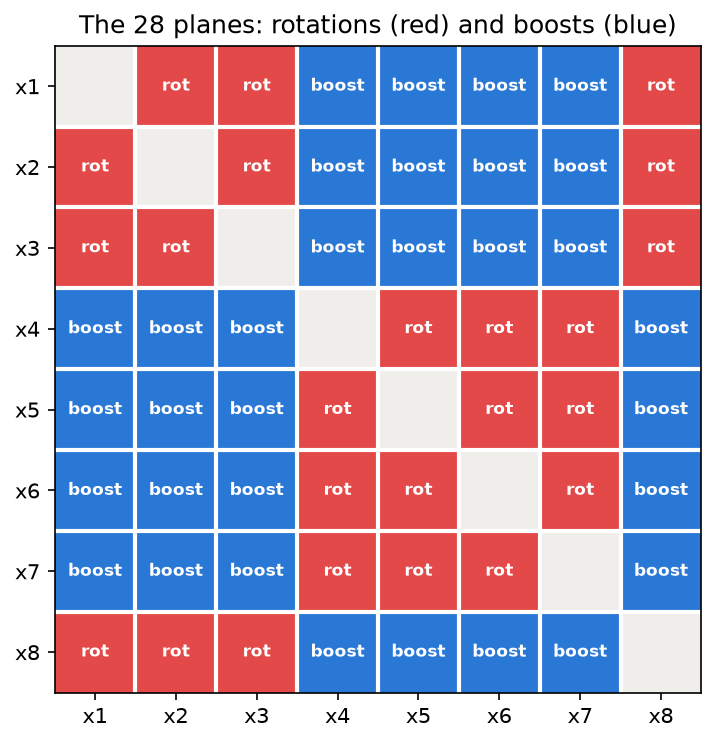

Figure 05d.1 saved as Revision/textbook/figures/05d_1_plane_types.png


In [5]:
kind = {}  # (a, b) -> +1 for a rotation, -1 for a boost
squares_ok = True
for a, b in pairs:
    J = gamma[a] @ gamma[b]
    squares_ok &= np.array_equal(J @ J, -ETA[a] * ETA[b] * I16)
    kind[(a, b)] = ETA[a] * ETA[b]
rotations = [p for p in pairs if kind[p] == 1]
boosts = [p for p in pairs if kind[p] == -1]
say(f"rotations: {len(rotations)}; boosts: {len(boosts)}")
say("rotation planes: " + " ".join(f"({a},{b})" for a, b in rotations))
check(squares_ok and len(rotations) == 12 and len(boosts) == 16,
      "(gamma^a gamma^b)^2 = -eta_aa eta_bb: 12 rotation planes and 16 boost planes")
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
table = np.zeros((8, 8))
for (a, b), value in kind.items():
    i, j = COORDS.index(a), COORDS.index(b)
    table[i, j] = table[j, i] = value  # the same plane in both orders
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.imshow(table, cmap=SIGNS, vmin=-1, vmax=1)
for i in range(8):
    for j in range(8):
        word = "" if i == j else ("rot" if table[i, j] == 1 else "boost")
        ax.text(j, i, word, ha="center", va="center", color="white", fontsize=8,
                fontweight="bold")
for k in range(1, 8):
    ax.axhline(k - 0.5, color="white", linewidth=2)
    ax.axvline(k - 0.5, color="white", linewidth=2)
ax.set_xticks(range(8), COORDS)
ax.set_yticks(range(8), COORDS)
ax.set_title("The 28 planes: rotations (red) and boosts (blue)")
ax.grid(False)
save_figure(fig, "plane_types",
            "The kind of the transformation $\\exp(\\theta S^{ab})$ in each coordinate "
            "plane $(a, b)$: row $a$ and column $b$ name the two directions; red rot "
            "means a rotation ($\\eta_{aa}\\eta_{bb} = +1$, $(\\gamma^a\\gamma^b)^2 = "
            "-1$), blue boost a boost ($\\eta_{aa}\\eta_{bb} = -1$, "
            "$(\\gamma^a\\gamma^b)^2 = +1$); the diagonal is empty. The 6 planes inside "
            "3-space plus the hidden direction and the 6 planes inside the four times "
            "are rotations; the 16 planes that mix a space-like with a time-like "
            "direction are boosts.")

## 8. The exponential: power series and closed formula

The next cell defines two ways of computing $R = \exp(\theta S^{ab})$: the power
series summed up to 80 terms (each term is the previous one times $M/k$), and the
closed formula of section 4. It compares them for two rotations, $(x1, x2)$ and
$(x4, x5)$, at the angles $0.3$, $1$, $2.5$, $2\pi$ and $4\pi$, and for two boosts,
$(x1, x4)$ and $(x5, x8)$, at the rapidities $-1.5$, $0.3$, $1$ and $2.5$. The
largest difference of any entry must be below $10^{-10}$ (the series is summed in
floating-point numbers).

In [6]:
def exp_series(M, terms=80):
    """exp(M) = 1 + M + M^2/2 + ... summed up to M^(terms-1)/(terms-1)!."""
    result = np.eye(M.shape[0])
    term = np.eye(M.shape[0])
    for k in range(1, terms):
        term = term @ M / k  # M^k / k! from M^(k-1) / (k-1)!
        result = result + term
    return result


def spin_transformation(a, b, theta):
    """exp(theta S^ab) from the closed formula with half angles."""
    J = (gamma[a] @ gamma[b]).astype(float)  # J = 2 S^ab
    if ETA[a] * ETA[b] == 1:  # J J = -1: a rotation
        return np.cos(theta / 2) * np.eye(16) + np.sin(theta / 2) * J
    return np.cosh(theta / 2) * np.eye(16) + np.sinh(theta / 2) * J  # a boost


tests = [(("x1", "x2"), [0.3, 1.0, 2.5, 2 * np.pi, 4 * np.pi]),
         (("x4", "x5"), [0.3, 1.0, 2.5, 2 * np.pi, 4 * np.pi]),
         (("x1", "x4"), [-1.5, 0.3, 1.0, 2.5]),
         (("x5", "x8"), [-1.5, 0.3, 1.0, 2.5])]
largest_difference = 0.0
for (a, b), angles in tests:
    for theta in angles:
        difference = np.max(np.abs(exp_series(theta * S[(a, b)])
                                   - spin_transformation(a, b, theta)))
        largest_difference = max(largest_difference, difference)
    name = "rotation" if kind[(a, b)] == 1 else "boost"
    say(f"plane ({a},{b}), a {name}: series and closed formula compared at "
        f"{len(angles)} values")
check(largest_difference < 1e-10,
      "the power series of exp(theta S^ab) equals the closed formula with half "
      "angles (difference below 1e-10)")

plane (x1,x2), a rotation: series and closed formula compared at 5 values
plane (x4,x5), a rotation: series and closed formula compared at 5 values
plane (x1,x4), a boost: series and closed formula compared at 4 values
plane (x5,x8), a boost: series and closed formula compared at 4 values
PASS the power series of exp(theta S^ab) equals the closed formula with half angles
    (difference below 1e-10)


## 9. How the directions move, and the sign after 2 pi

The next cell defines `vector_matrix(R)`, the $8 \times 8$ matrix $\Lambda$ with
$R\gamma^cR^{-1} = \sum_d\Lambda_{dc}\gamma^d$, read off with the trace formula of
section 4, and checks for the rotation in the plane $(x1, x2)$ at nine angles that:
the sum $\sum_d \Lambda_{dc}\gamma^d$ rebuilds $R\gamma^cR^{-1}$; $\Lambda$ is the
rotation by the full angle $\theta$ (entries $\cos\theta$ and $\pm\sin\theta$ in the
$(x1, x2)$ block, the identity elsewhere); $\Lambda^T\eta\Lambda = \eta$ and
$\det\Lambda = 1$ (it lies in SO(4,4)). Then it checks the double cover:
$R(2\pi) = -1$ and $R(4\pi) = +1$, while $\Lambda(2\pi) = \Lambda(4\pi) = 1$.

In [7]:
def vector_matrix(R):
    """Lambda (8 x 8) with R gamma^c R^-1 = sum over d of Lambda_dc gamma^d."""
    R_inverse = np.linalg.inv(R)
    Lam = np.zeros((8, 8))
    for j, c in enumerate(COORDS):
        moved = R @ gamma[c] @ R_inverse  # where the direction c is moved to
        for i, d in enumerate(COORDS):
            Lam[i, j] = ETA[d] * np.trace(gamma[d] @ moved) / 16.0
    return Lam


def rebuilds(R, Lam):
    """True when sum_d Lambda_dc gamma^d equals R gamma^c R^-1 for every c."""
    R_inverse = np.linalg.inv(R)
    return all(np.allclose(sum(Lam[i, j] * gamma[d] for i, d in enumerate(COORDS)),
                           R @ gamma[c] @ R_inverse, atol=1e-12)
               for j, c in enumerate(COORDS))


rotation_ok = True
for theta in np.linspace(0.0, 2 * np.pi, 9):
    R = spin_transformation("x1", "x2", theta)
    Lam = vector_matrix(R)
    expected = np.eye(8)  # the rotation by theta in the (x1, x2) block
    expected[0, 0] = expected[1, 1] = np.cos(theta)
    expected[0, 1], expected[1, 0] = np.sin(theta), -np.sin(theta)
    rotation_ok &= (rebuilds(R, Lam) and np.allclose(Lam, expected, atol=1e-12)
                    and np.allclose(Lam.T @ ETA_MATRIX @ Lam, ETA_MATRIX)
                    and abs(np.linalg.det(Lam) - 1.0) < 1e-12)
check(rotation_ok,
      "R = exp(theta S^(x1 x2)) turns the directions x1, x2 by the full angle "
      "theta; Lambda lies in SO(4,4)")
R_2pi, R_4pi = spin_transformation("x1", "x2", 2 * np.pi), spin_transformation(
    "x1", "x2", 4 * np.pi)
# Rounding leaves differences of about 1e-16, which differ between computers, so
# the cell prints only whether they are below 1e-12.
small_2pi = np.max(np.abs(R_2pi + np.eye(16))) < 1e-12
small_4pi = np.max(np.abs(R_4pi - np.eye(16))) < 1e-12
say(f"every entry of R(2 pi) + 1 is below 1e-12: {small_2pi}; "
    f"every entry of R(4 pi) - 1 is below 1e-12: {small_4pi}")
check(np.allclose(R_2pi, -np.eye(16), atol=1e-12)
      and np.allclose(R_4pi, np.eye(16), atol=1e-12)
      and np.allclose(vector_matrix(R_2pi), np.eye(8), atol=1e-12),
      "a rotation by 2 pi gives R = -1 on spinors but Lambda = 1 on vectors; by 4 pi, R "
      "= +1")

PASS R = exp(theta S^(x1 x2)) turns the directions x1, x2 by the full angle theta; Lambda
    lies in SO(4,4)
every entry of R(2 pi) + 1 is below 1e-12: True; every entry of R(4 pi) - 1 is below
    1e-12: True
PASS a rotation by 2 pi gives R = -1 on spinors but Lambda = 1 on vectors; by 4 pi, R =
    +1


The next cell draws the half angles. Left: for the rotation in the plane
$(x1, x2)$, the vector entry $\Lambda_{x1,x1} = \cos\theta$ and the spinor quantity
$\mathrm{tr}R/16 = \cos(\theta/2)$ (the trace of $J$ is zero), for $\theta$ from 0
to $4\pi$. Right: for the boost in the plane $(x1, x4)$, $\Lambda_{x1,x1} =
\cosh\theta$ and $\mathrm{tr}R/16 = \cosh(\theta/2)$, for $\theta$ from $-3$ to 3.
The values are computed from the matrices, then compared with the formulas.

PASS vectors move with cos(theta), cosh(theta); spinors with the half angle


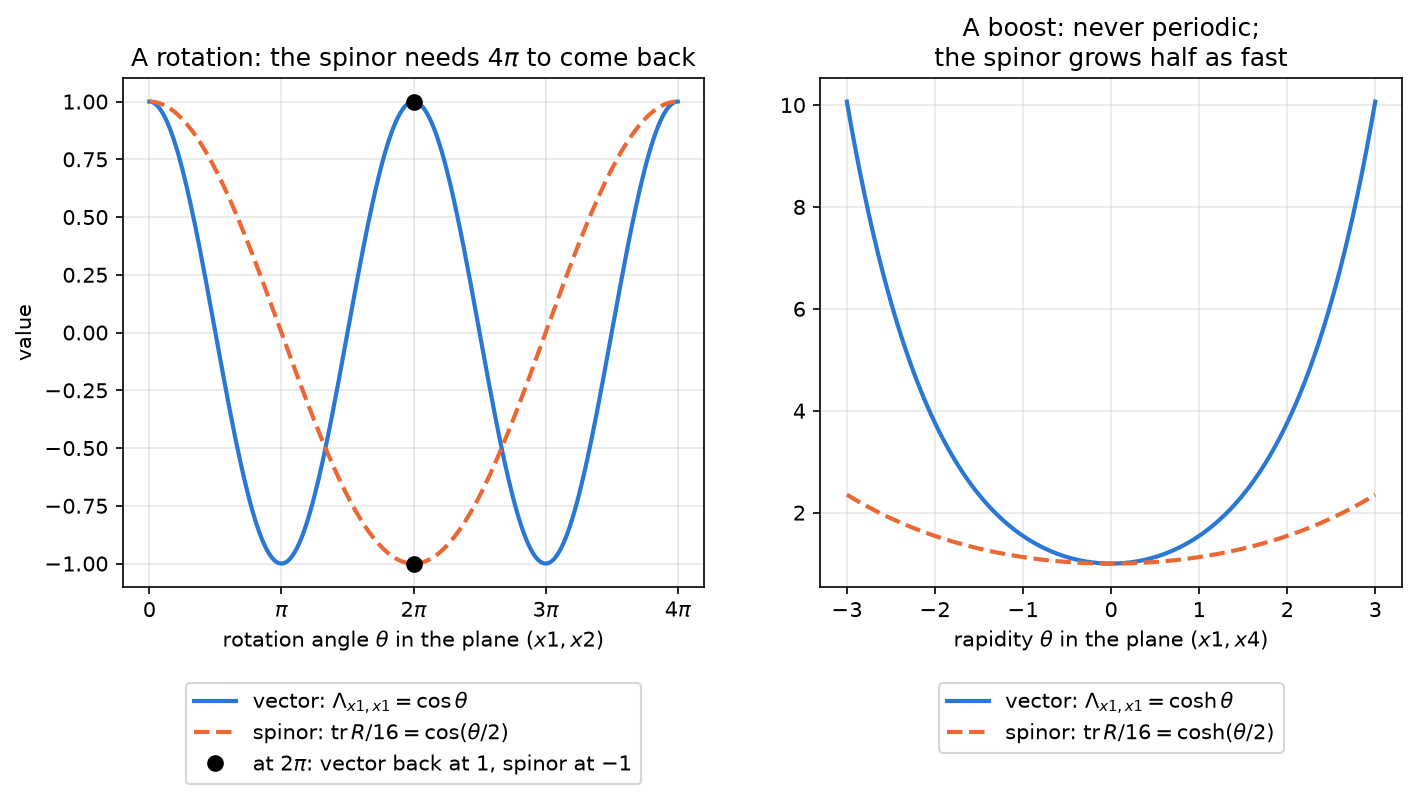

Figure 05d.2 saved as Revision/textbook/figures/05d_2_half_angles.png


In [8]:
angles = np.linspace(0.0, 4 * np.pi, 241)
rapidities = np.linspace(-3.0, 3.0, 241)
vec_rot = [vector_matrix(spin_transformation("x1", "x2", th))[0, 0] for th in angles]
spin_rot = [np.trace(spin_transformation("x1", "x2", th)) / 16 for th in angles]
vec_boost = [vector_matrix(spin_transformation("x1", "x4", th))[0, 0]
             for th in rapidities]
spin_boost = [np.trace(spin_transformation("x1", "x4", th)) / 16 for th in rapidities]
check(np.allclose(vec_rot, np.cos(angles)) and np.allclose(spin_rot, np.cos(angles / 2))
      and np.allclose(vec_boost, np.cosh(rapidities))
      and np.allclose(spin_boost, np.cosh(rapidities / 2)),
      "vectors move with cos(theta), cosh(theta); spinors with the half angle")
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
axes[0].plot(angles, vec_rot, color="#2a78d6", linewidth=2,
             label=r"vector: $\Lambda_{x1,x1} = \cos\theta$")
axes[0].plot(angles, spin_rot, color="#eb6834", linewidth=2, linestyle="--",
             label=r"spinor: $\mathrm{tr}\,R/16 = \cos(\theta/2)$")
axes[0].plot([2 * np.pi, 2 * np.pi], [1.0, -1.0], "o", color="black", markersize=7,
             label=r"at $2\pi$: vector back at $1$, spinor at $-1$")
axes[0].set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi],
                   ["0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"])
axes[0].set_xlabel(r"rotation angle $\theta$ in the plane $(x1, x2)$")
axes[0].set_ylabel("value")
axes[0].set_title("A rotation: the spinor needs $4\\pi$ to come back")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17))
axes[1].plot(rapidities, vec_boost, color="#2a78d6", linewidth=2,
             label=r"vector: $\Lambda_{x1,x1} = \cosh\theta$")
axes[1].plot(rapidities, spin_boost, color="#eb6834", linewidth=2, linestyle="--",
             label=r"spinor: $\mathrm{tr}\,R/16 = \cosh(\theta/2)$")
axes[1].set_xlabel(r"rapidity $\theta$ in the plane $(x1, x4)$")
axes[1].set_title("A boost: never periodic;\nthe spinor grows half as fast")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17))
save_figure(fig, "half_angles",
            "Vectors and spinors under a rotation and a boost. Left: for the rotation "
            "$\\exp(\\theta S^{ab})$ in the plane $(x1, x2)$, the vector entry "
            "$\\cos\\theta$ (solid) and the spinor quantity $\\mathrm{tr}\\,R/16 = "
            "\\cos(\\theta/2)$ (dashed) against the angle $\\theta$ from $0$ to "
            "$4\\pi$; at $2\\pi$ the vector is back at 1 while the spinor matrix is "
            "$-1$ (dots), and only at $4\\pi$ both are back. Right: for the boost in "
            "the plane $(x1, x4)$, $\\cosh\\theta$ and $\\cosh(\\theta/2)$ against the "
            "rapidity from $-3$ to $3$; a boost never returns. Vertical axes: pure "
            "numbers.")

The next cell draws $R(\theta) = \exp(\theta S^{(x1\,x2)})$ as heat maps at
$\theta = 0$ (the identity), $\pi$ (then $R = \gamma^{(x1)}\gamma^{(x2)}$, because
$\cos\tfrac\pi2 = 0$ and $\sin\tfrac\pi2 = 1$), $2\pi$ (then $R = -1$) and $4\pi$
(then $R = +1$).

PASS R(pi) = gamma^(x1) gamma^(x2) for the rotation in the plane (x1, x2)


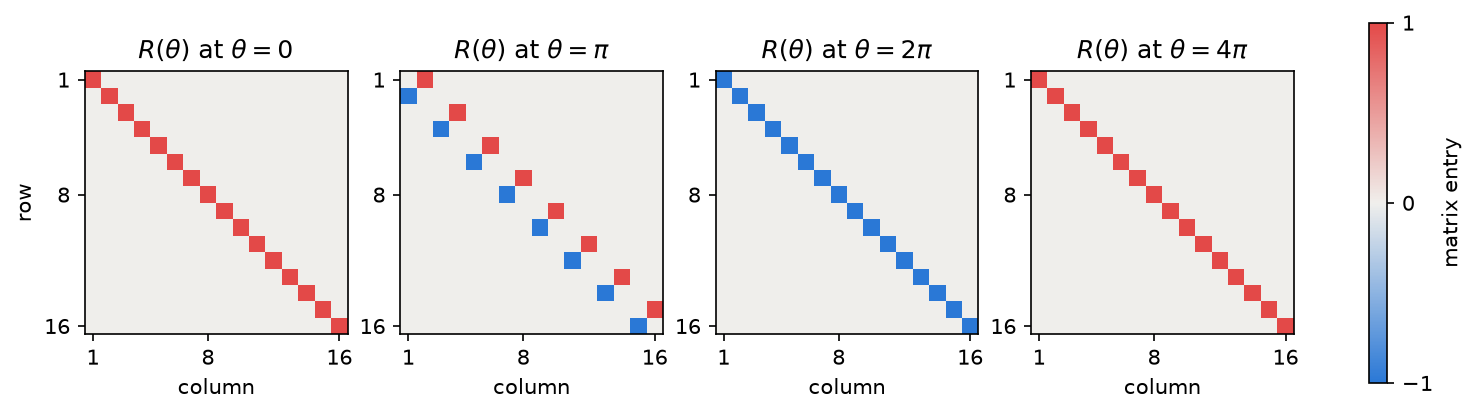

Figure 05d.3 saved as Revision/textbook/figures/05d_3_rotation_matrices.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.9))
for k, (ax, th, label) in enumerate(zip(
        axes, [0.0, np.pi, 2 * np.pi, 4 * np.pi], ["0", r"\pi", r"2\pi", r"4\pi"])):
    image = ax.imshow(spin_transformation("x1", "x2", th), cmap=SIGNS, vmin=-1,
                      vmax=1)
    ax.set_title(rf"$R(\theta)$ at $\theta = {label}$")
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.set_xlabel("column")
    if k == 0:
        ax.set_ylabel("row")
    ax.grid(False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
check(np.allclose(spin_transformation("x1", "x2", np.pi),
                  gamma["x1"] @ gamma["x2"], atol=1e-12),
      "R(pi) = gamma^(x1) gamma^(x2) for the rotation in the plane (x1, x2)")
save_figure(fig, "rotation_matrices",
            "The spinor rotation $R(\\theta) = \\exp(\\theta S^{ab})$ in the plane "
            "$(x1, x2)$ at the angles $0$, $\\pi$, $2\\pi$ and $4\\pi$, as heat maps "
            "(column and row 1 to 16; blue $-1$, grey $0$, red $+1$). At $0$ it is "
            "the identity; at $\\pi$ it is the product "
            "$\\gamma^{(x1)}\\gamma^{(x2)}$; at $2\\pi$ it is minus the identity "
            "(every diagonal entry blue), although the directions are back where "
            "they started; only at $4\\pi$ is it the identity again.")

## 10. Circles and hyperbolas

A rotation keeps $v_1^2 + v_2^2$, a boost keeps $v_1^2 - v_4^2$ (the metric product
in that plane, because $\eta_{x4\,x4} = -1$). The next cell moves the unit vector
$e_{x1}$ with the rotation in $(x1, x2)$ for $\theta$ from 0 to $2\pi$ (it runs
around a circle), and the unit vectors $e_{x1}$ and $e_{x4}$ with the boost in
$(x1, x4)$ for $\theta$ from $-2$ to 2 (they run along the two branches of the
hyperbolas $v_1^2 - v_4^2 = +1$ and $= -1$). The vector matrices are again computed
from the spinor matrices.

PASS rotations keep v1^2 + v2^2, boosts keep v1^2 - v4^2


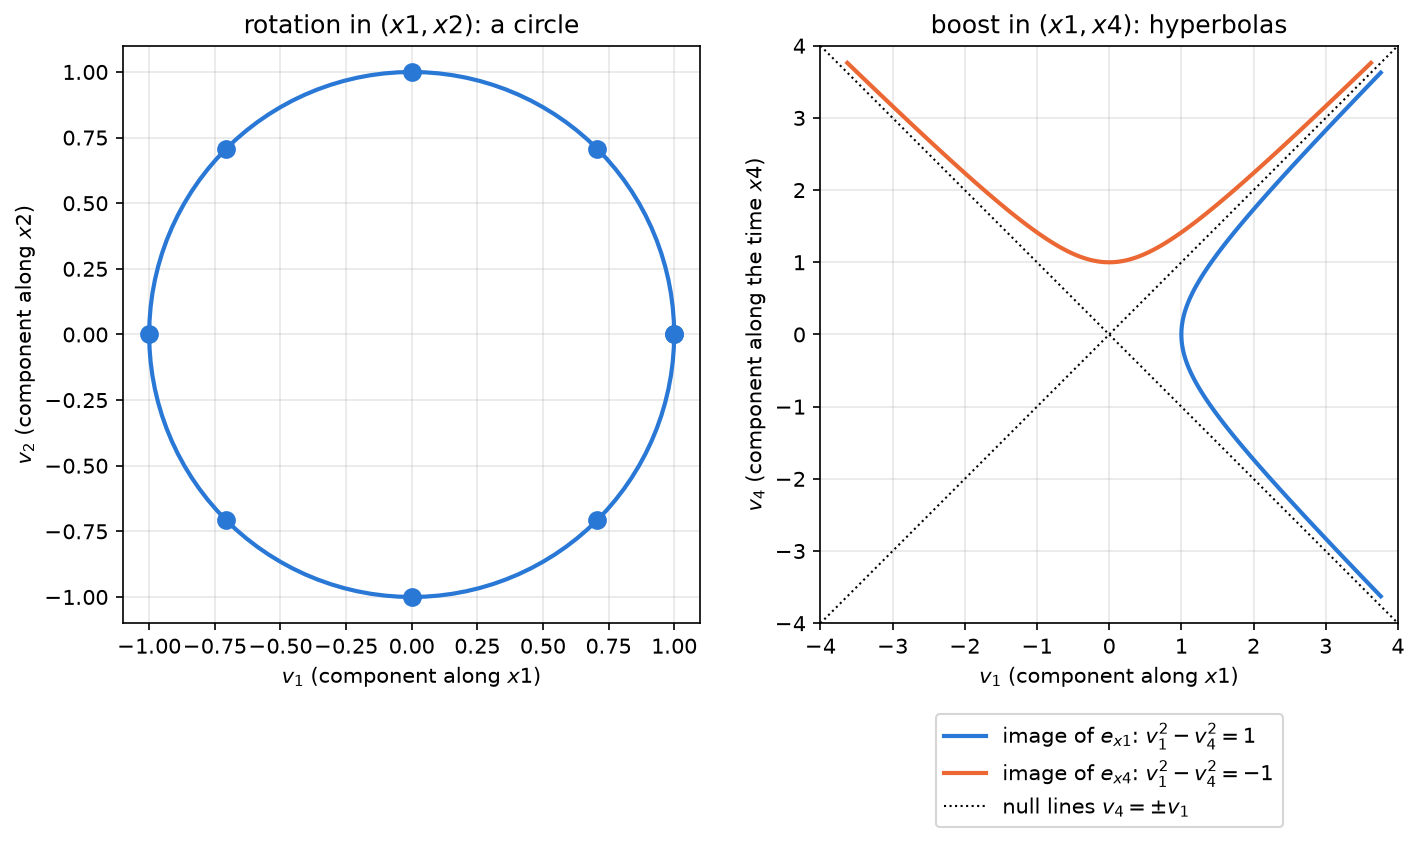

Figure 05d.4 saved as Revision/textbook/figures/05d_4_orbits.png


In [10]:
circle = np.array([vector_matrix(spin_transformation("x1", "x2", th))[:, 0]
                   for th in np.linspace(0.0, 2 * np.pi, 121)])  # images of e_x1
hyper_space = np.array([vector_matrix(spin_transformation("x1", "x4", th))[:, 0]
                        for th in np.linspace(-2.0, 2.0, 121)])  # images of e_x1
hyper_time = np.array([vector_matrix(spin_transformation("x1", "x4", th))[:, 3]
                       for th in np.linspace(-2.0, 2.0, 121)])  # images of e_x4
check(np.allclose(circle[:, 0] ** 2 + circle[:, 1] ** 2, 1.0)
      and np.allclose(hyper_space[:, 0] ** 2 - hyper_space[:, 3] ** 2, 1.0)
      and np.allclose(hyper_time[:, 0] ** 2 - hyper_time[:, 3] ** 2, -1.0),
      "rotations keep v1^2 + v2^2, boosts keep v1^2 - v4^2")
fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))
axes[0].plot(circle[:, 0], circle[:, 1], color="#2a78d6", linewidth=2)
axes[0].plot(circle[::15, 0], circle[::15, 1], "o", color="#2a78d6", markersize=8)
axes[0].set_aspect("equal")
axes[0].set_xlabel("$v_1$ (component along $x1$)")
axes[0].set_ylabel("$v_2$ (component along $x2$)")
axes[0].set_title("rotation in $(x1, x2)$: a circle")
axes[1].plot(hyper_space[:, 0], hyper_space[:, 3], color="#2a78d6", linewidth=2,
             label=r"image of $e_{x1}$: $v_1^2 - v_4^2 = 1$")
axes[1].plot(hyper_time[:, 0], hyper_time[:, 3], color="#eb6834", linewidth=2,
             label=r"image of $e_{x4}$: $v_1^2 - v_4^2 = -1$")
axes[1].plot([-4, 4], [-4, 4], ":", color="black", linewidth=1,
             label="null lines $v_4 = \\pm v_1$")
axes[1].plot([-4, 4], [4, -4], ":", color="black", linewidth=1)
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-4, 4)
axes[1].set_aspect("equal")
axes[1].set_xlabel("$v_1$ (component along $x1$)")
axes[1].set_ylabel("$v_4$ (component along the time $x4$)")
axes[1].set_title("boost in $(x1, x4)$: hyperbolas")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14))
save_figure(fig, "orbits",
            "Where the transformations carry a unit vector. Left: the rotation in "
            "the plane $(x1, x2)$ carries the unit vector along $x1$ around the "
            "circle $v_1^2 + v_2^2 = 1$ as the angle runs from $0$ to $2\\pi$ (dots "
            "every $\\pi/4$). Right: the boost in the plane $(x1, x4)$ carries the "
            "unit vector along $x1$ along the hyperbola $v_1^2 - v_4^2 = 1$ (blue) "
            "and the unit vector along the time $x4$ along $v_1^2 - v_4^2 = -1$ "
            "(orange), for rapidities from $-2$ to $2$; neither crosses the dotted "
            "null lines. Axes: the components of the vector (pure numbers).")

## 11. Which forms are kept: C always, B only away from the time x4

Because $(S^{ab})^TC + CS^{ab} = 0$ for every generator, every exponential keeps the
form of $C$: $R^TCR = C$. The form of $B$ (the charge density $\Psi^\dagger B\Psi$)
is different: the recorded check states that $(S^{ab})^\dagger B + BS^{ab} = 0$
holds exactly for the 21 generators that do not involve $x4$, and that for the 7
generators $S^{(x4)\,b}$ it equals $iC\gamma^b \neq 0$. The next cell checks this
generator by generator, and then for finite transformations: $R^TCR - C$ and
$R^\dagger BR - B$ ($R$ is real, so $R^\dagger = R^T$) for all 28 planes at
$\theta = 0.7$.

In [11]:
keep_B = [p for p in pairs if not (S[p].T @ B + B @ S[p]).any()]
break_B = [p for p in pairs if p not in keep_B]
rule_x4 = all(np.array_equal(S[("x4", b)].T @ B + B @ S[("x4", b)],
                             1j * (C @ gamma[b])) for b in COORDS if b != "x4")
say(f"generators with S^T B + B S = 0: {len(keep_B)}; the others: "
    + " ".join(f"({a},{b})" for a, b in break_B))
check_reproduces(len(keep_B) == 21 and all("x4" in p for p in break_B) and rule_x4
                 and recorded("wolfram", "S_preserves_B_only_off_x4"),
                 "S^dagger B + B S = 0 exactly for the 21 generators without x4; for "
                 "S^(x4 b) it equals i C gamma^b",
                 record=record_of("wolfram", "S_preserves_B_only_off_x4"))
finite_C = max(np.max(np.abs(spin_transformation(a, b, 0.7).T @ C
                             @ spin_transformation(a, b, 0.7) - C)) for a, b in pairs)
finite_B = {p: np.max(np.abs(spin_transformation(*p, 0.7).T @ B
                             @ spin_transformation(*p, 0.7) - B)) for p in pairs}
check(finite_C < 1e-12 and all((finite_B[p] < 1e-12) == (p in keep_B) for p in pairs),
      "at theta = 0.7: R^T C R = C for all 28 planes; R^T B R = B exactly for the 21 "
      "planes without x4")

generators with S^T B + B S = 0: 21; the others: (x1,x4) (x2,x4) (x3,x4) (x4,x5) (x4,x6)
    (x4,x7) (x4,x8)
PASS S^dagger B + B S = 0 exactly for the 21 generators without x4; for S^(x4 b) it
    equals i C gamma^b
     reproduces Revision/algebra/reports/wolfram-algebra.json, check
    S_preserves_B_only_off_x4
PASS at theta = 0.7: R^T C R = C for all 28 planes; R^T B R = B exactly for the 21 planes
    without x4


The next cell draws, as functions of $\theta$, the size of the change of the form
of $B$ (the largest entry of $R^TBR - B$) for four planes: the rotations $(x1,
x2)$ and $(x5, x6)$ (no $x4$: no change), the boost $(x1, x4)$ and the rotation
$(x4, x5)$ (both involve $x4$), and the change of the form of $C$ for all four.

largest change of the form of C over the four planes and all angles: below 1e-12


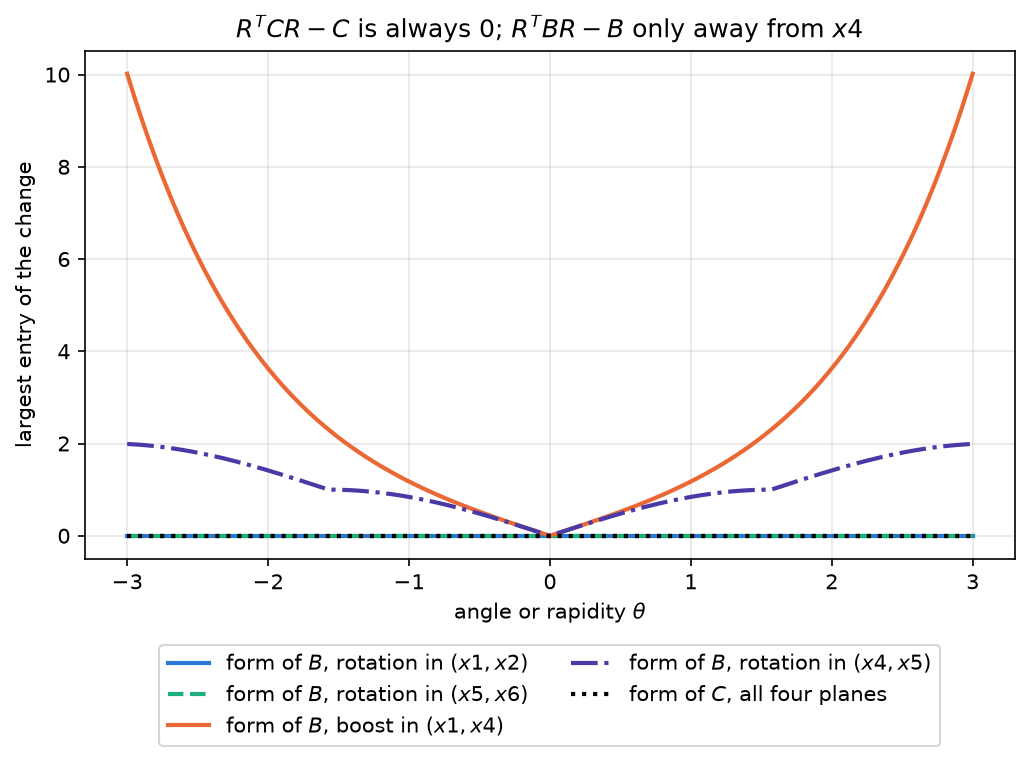

Figure 05d.5 saved as Revision/textbook/figures/05d_5_invariant_forms.png


In [12]:
thetas = np.linspace(-3.0, 3.0, 241)
planes = [("x1", "x2"), ("x5", "x6"), ("x1", "x4"), ("x4", "x5")]
colors = ["#2a78d6", "#1baf7a", "#eb6834", "#4a3aa7"]
lines = ["-", "--", "-", "-."]
change_B = {p: [np.max(np.abs(spin_transformation(*p, th).T @ B
                              @ spin_transformation(*p, th) - B)) for th in thetas]
            for p in planes}
change_C = max(np.max(np.abs(spin_transformation(*p, th).T @ C
                             @ spin_transformation(*p, th) - C))
               for p in planes for th in thetas)
shown = "below 1e-12" if change_C < 1e-12 else f"{change_C:.2e}"
say(f"largest change of the form of C over the four planes and all angles: {shown}")
fig, ax = plt.subplots(figsize=(8.0, 4.4))
for p, color, line in zip(planes, colors, lines):
    name = "rotation" if kind[p] == 1 else "boost"
    ax.plot(thetas, change_B[p], color=color, linestyle=line, linewidth=2,
            label=f"form of $B$, {name} in $({p[0]}, {p[1]})$")
ax.plot(thetas, np.zeros_like(thetas), ":", color="black", linewidth=2,
        label="form of $C$, all four planes")
ax.set_xlabel(r"angle or rapidity $\theta$")
ax.set_ylabel("largest entry of the change")
ax.set_title(r"$R^T C R - C$ is always 0; $R^T B R - B$ only away from $x4$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
save_figure(fig, "invariant_forms",
            "How much the transformation $R = \\exp(\\theta S^{ab})$ changes the "
            "forms of $B$ and of $C$: the largest entry of $R^T B R - B$ against "
            "$\\theta$ from $-3$ to $3$ for the rotations in $(x1, x2)$ and $(x5, "
            "x6)$ (both exactly zero, on the horizontal axis), the boost in $(x1, "
            "x4)$ and the rotation in $(x4, x5)$ (both nonzero), and the largest "
            "entry of $R^T C R - C$ for all four (dotted, zero). The bilinear "
            "$\\Psi^\\dagger C\\Psi$ is invariant under all of Spin(4,4); the charge "
            "density $\\Psi^\\dagger B\\Psi$ only under the transformations that "
            "leave the time $x4$ alone.")

## 12. Reflections, the spinor norm, the double cover and the determinants

The next cell checks the reflection identity $-\gamma(u)\gamma(v)\gamma(u)^{-1} =
\gamma(R_uv)$ of section 4 for three unit vectors: $u = e_{x1}$ (space-like,
$\eta(u, u) = +1$), $u = e_{x4}$ (time-like, $-1$) and the tilted unit vector
$u = \cosh(0.5)\,e_{x1} + \sinh(0.5)\,e_{x4}$ (with $\eta(u, u) = \cosh^2 -
\sinh^2 = 1$), each with the fixed vector $v = (1, 2, \dots, 8)/10$, and that every
reflection has determinant $-1$ and keeps the metric.

In [13]:
def gamma_of(v):
    """gamma(v) = sum over a of v_a gamma^a."""
    return sum(v[i] * gamma[x].astype(float) for i, x in enumerate(COORDS))


def metric_product(u, v):
    """eta(u, v) = sum over a of eta_aa u_a v_a."""
    return float(u @ ETA_MATRIX @ v)


def reflection(u):
    """The 8 x 8 matrix of R_u v = v - 2 eta(u, v) u / eta(u, u)."""
    return np.eye(8) - 2.0 * np.outer(u, u @ ETA_MATRIX) / metric_product(u, u)


e = np.eye(8)  # e[i] is the unit vector along COORDS[i]
tilted = np.cosh(0.5) * e[0] + np.sinh(0.5) * e[3]
v = np.arange(1, 9) / 10.0
reflections_ok = True
for u in (e[0], e[3], tilted):
    gu = gamma_of(u)
    left = -gu @ gamma_of(v) @ np.linalg.inv(gu)
    Ru = reflection(u)
    reflections_ok &= (np.allclose(left, gamma_of(Ru @ v), atol=1e-12)
                       and abs(np.linalg.det(Ru) + 1.0) < 1e-12
                       and np.allclose(Ru.T @ ETA_MATRIX @ Ru, ETA_MATRIX))
    say(f"eta(u, u) = {metric_product(u, u):+.6f}: reflection checked")
check(reflections_ok,
      "-gamma(u) gamma(v) gamma(u)^-1 = gamma(R_u v); det R_u = -1; R_u keeps eta")

eta(u, u) = +1.000000: reflection checked
eta(u, u) = -1.000000: reflection checked
eta(u, u) = +1.000000: reflection checked
PASS -gamma(u) gamma(v) gamma(u)^-1 = gamma(R_u v); det R_u = -1; R_u keeps eta


The next cell checks the spinor norm formula $g^TCg = (-1)^kN(g)\,C$ for five
elements: $\gamma^{(x1)}$, $\gamma^{(x4)}$, $\gamma^{(x1)}\gamma^{(x4)}$,
$\gamma(\text{tilted})\gamma^{(x5)}$ and $\Gamma$ (a product of eight gammas with
$N = (+1)^4(-1)^4 = +1$). The element $\gamma^{(x1)}\gamma^{(x4)}$ belongs to
Spin(4,4) (two factors) but has $g^TCg = -C$: since every product of exponentials
keeps $C$ (section 4), it is **not** a product of exponentials. The cell also checks
that $\Gamma$ moves every direction to its opposite ($\Lambda = -1_8$, determinant
$(-1)^8 = +1$), and the double cover along the rotation: $R(\theta + 2\pi) =
-R(\theta)$ but both give the same $\Lambda$.

In [14]:
elements = [("gamma^(x1)", [e[0]]), ("gamma^(x4)", [e[3]]),
            ("gamma^(x1) gamma^(x4)", [e[0], e[3]]),
            ("gamma(tilted) gamma^(x5)", [tilted, e[4]]),
            ("Gamma", [e[7]] + [e[i] for i in range(7)])]
norm_ok = True
for name, factors in elements:
    g = np.eye(16)
    for u in factors:
        g = g @ gamma_of(u)
    k = len(factors)
    N = int(round(np.prod([metric_product(u, u) for u in factors])))
    predicted = (-1) ** k * N
    norm_ok &= np.allclose(g.T @ C @ g, predicted * C, atol=1e-12)
    say(f"{name:26} k = {k}, N(g) = {N:+d}: g^T C g = {predicted:+d} C")
check(norm_ok, "g^T C g = (-1)^k N(g) C for all five elements")
check(np.allclose(vector_matrix(Gamma.astype(float)), -np.eye(8), atol=1e-12),
      "Gamma moves every direction to its opposite: Lambda(Gamma) = -1 (det +1)")
cover_ok = all(
    np.allclose(spin_transformation("x1", "x2", th + 2 * np.pi),
                -spin_transformation("x1", "x2", th), atol=1e-12)
    and np.allclose(vector_matrix(spin_transformation("x1", "x2", th + 2 * np.pi)),
                    vector_matrix(spin_transformation("x1", "x2", th)), atol=1e-12)
    for th in np.linspace(0.0, 2 * np.pi, 7))
check(cover_ok, "R(theta + 2 pi) = -R(theta), and both move the vectors in the "
      "same way: two spinor matrices for every vector matrix")

gamma^(x1)                 k = 1, N(g) = +1: g^T C g = -1 C
gamma^(x4)                 k = 1, N(g) = -1: g^T C g = +1 C
gamma^(x1) gamma^(x4)      k = 2, N(g) = -1: g^T C g = -1 C
gamma(tilted) gamma^(x5)   k = 2, N(g) = -1: g^T C g = -1 C
Gamma                      k = 8, N(g) = +1: g^T C g = +1 C
PASS g^T C g = (-1)^k N(g) C for all five elements
PASS Gamma moves every direction to its opposite: Lambda(Gamma) = -1 (det +1)
PASS R(theta + 2 pi) = -R(theta), and both move the vectors in the same way: two spinor
    matrices for every vector matrix


The next cell computes the determinants of the eight gammas exactly with sympy
(as $16 \times 16$ matrices). Each is $+1$ (a gamma with $\gamma\gamma = +1$ and
trace 0 has eigenvalues $+1$ and $-1$ eight times each, product $(+1)^8(-1)^8 = 1$;
one with $\gamma\gamma = -1$ has $\pm i$ eight times each, product $i^8(-i)^8 = 1$).
So every element of Pin(4,4), a product of such matrices, has determinant 1 as a
$16 \times 16$ matrix: "determinant 1" in "Spin(4,4) covers SO(4,4)" refers to the
vector matrix $\Lambda$, never to the spinor matrix.

In [15]:
import sympy as sp  # exact algebra

determinants = {x: sp.Matrix(gamma[x].tolist()).det() for x in COORDS}
say("det gamma^(x) = " + ", ".join(f"{x}: {determinants[x]}" for x in COORDS))
check(all(d == 1 for d in determinants.values()),
      "every gamma matrix has determinant +1 as a 16 x 16 matrix")

det gamma^(x) = x1: 1, x2: 1, x3: 1, x4: 1, x5: 1, x6: 1, x7: 1, x8: 1
PASS every gamma matrix has determinant +1 as a 16 x 16 matrix


## 13. The vector matrices as pictures

The next cell draws four $8 \times 8$ vector matrices: the rotation by $\pi/3$ in
$(x1, x2)$, the boost with rapidity 1 in $(x1, x4)$, the reflection $R_u$ along
$u = e_{x1}$, and $\Lambda(\Gamma) = -1_8$. The colour scale runs from $-1.6$ to
$+1.6$ because a boost has entries $\cosh 1 \approx 1.54$.

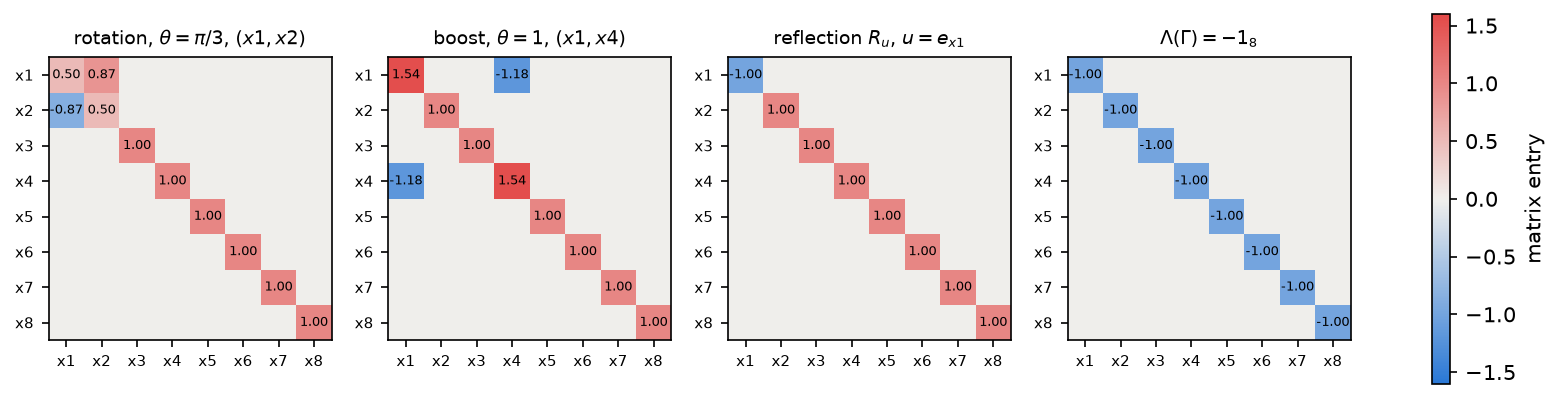

Figure 05d.6 saved as Revision/textbook/figures/05d_6_vector_matrices.png


In [16]:
pictures = [(vector_matrix(spin_transformation("x1", "x2", np.pi / 3)),
             r"rotation, $\theta = \pi/3$, $(x1, x2)$"),
            (vector_matrix(spin_transformation("x1", "x4", 1.0)),
             r"boost, $\theta = 1$, $(x1, x4)$"),
            (reflection(e[0]), r"reflection $R_u$, $u = e_{x1}$"),
            (vector_matrix(Gamma.astype(float)), r"$\Lambda(\Gamma) = -1_8$")]
fig, axes = plt.subplots(1, 4, figsize=(14.0, 4.0))
for k, (ax, (matrix, title)) in enumerate(zip(axes, pictures)):
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1.6, vmax=1.6)
    for i in range(8):
        for j in range(8):
            if abs(matrix[i, j]) > 1e-12:  # write the nonzero entries
                ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                        fontsize=6)
    ax.set_xticks(range(8), COORDS, fontsize=7)
    ax.set_yticks(range(8), COORDS, fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.grid(False)
fig.colorbar(image, ax=axes, shrink=0.8, label="matrix entry")
save_figure(fig, "vector_matrices",
            "Four 8 by 8 matrices by which transformations move the eight "
            "directions (rows and columns labelled $x1$ to $x8$; blue negative, "
            "grey 0, red positive; nonzero entries written in the squares): the "
            "rotation by $\\pi/3$ in the plane $(x1, x2)$ (entries $\\cos$ and "
            "$\\pm\\sin$ of $\\pi/3$), the boost with rapidity 1 in the plane "
            "$(x1, x4)$ (entries $\\cosh 1$ and $-\\sinh 1$), the reflection along "
            "$x1$ (one entry $-1$) and the matrix of the chirality $\\Gamma$, which "
            "reverses all eight directions.")

## 14. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [17]:
FIGURES = ["05d_1_plane_types.png", "05d_2_half_angles.png",
           "05d_3_rotation_matrices.png", "05d_4_orbits.png",
           "05d_5_invariant_forms.png", "05d_6_vector_matrices.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the six figure files of notebook 05d exist")
all_checks_passed()

PASS the six figure files of notebook 05d exist
ALL 20 CHECKS PASSED (notebook 05d)


## 15. What this notebook showed

- The 28 generators $S^{ab} = \tfrac12\gamma^a\gamma^b$ of the Revision gammas obey
  the rules of the Lie algebra so(4,4), turn the gammas like a vector, keep the form
  of $C$ and commute with $\Gamma$, as the Revision record states.
- 12 coordinate planes give rotations ($\cos$, $\sin$ of half the angle), 16 give
  boosts ($\cosh$, $\sinh$ of half the rapidity); the closed formulas agree with
  the power series of the exponential.
- The spinor matrix contains the half angle and the vector matrix the full angle:
  a rotation by $2\pi$ returns every direction but gives $R = -1$ on spinors; only
  $4\pi$ gives $R = +1$. $R$ and $-R$ move the vectors in the same way: the spinor
  group is a double cover of the group of vector transformations.
- Every spinor transformation keeps the form $\Psi^\dagger C\Psi$; the charge
  density $\Psi^\dagger B\Psi$ is kept only by the 21 generators (and their
  exponentials) that do not involve the time $x4$.
- Conjugation by a unit vector is a reflection (up to a sign), with determinant
  $-1$; the spinor norm $g^TCg = (-1)^kN(g)C$ holds; $\gamma^{(x1)}\gamma^{(x4)}$
  lies in Spin(4,4) but is not a product of exponentials; $\Gamma$ reverses all
  eight directions; every gamma has determinant $+1$ as a $16 \times 16$ matrix.